In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Divergences and Distances Between Distributions

Strip away the architecture diagrams and every modern generative model is the
same optimization problem: *make my model's distribution close to the data's*.
A language model pushes its next-token distribution toward the corpus; a VAE
pushes an approximate posterior toward the true one; a GAN pushes generated
images toward real ones; a diffusion model pushes a learned vector field toward
the data's score. What distinguishes these model families is the **notion of
"close"**: that choice silently determines the training objective, the
gradients it produces, and the characteristic ways it fails.

In that section we built one such notion, the
Kullback--Leibler divergence, and saw that minimizing it is maximum likelihood.
This section builds the rest of the map. There are three great families:
*f-divergences*, which average a convex function of the density ratio $p/q$
(KL, reverse KL, $\chi^2$, Hellinger, Jensen--Shannon); *integral probability
metrics*, which measure the largest gap in expectation any test function from a
chosen class can detect (total variation, MMD, Wasserstein-1); and *optimal
transport* distances, which measure how far probability mass must move. We
prove the short, structural results that organize the families: Jensen for
non-negativity, Fenchel duality for the adversarial (f-GAN) view, Pinsker's
inequality tying total variation to KL, and Kantorovich--Rubinstein duality
with the one-dimensional closed form for Wasserstein. We close with the *score*:
the gradient $\nabla_{\mathbf{x}} \log p(\mathbf{x})$ of the log-density with
respect to the data, the object on which all of
that section runs. The capstone is a table
that reads off, for each modern generative objective, which divergence it
secretly minimizes.

As in that section, **every logarithmic quantity is in
nats** (natural logarithms); bits are a fixed $\ln 2$ rescaling. Not every
divergence carries units, though: KL, reverse KL, and Jensen--Shannon are in
nats, but total variation, $\chi^2$, and squared Hellinger contain no logarithm
and are dimensionless, and transport distances carry the units of the sample
space itself. After the imports, everything below is plain NumPy and SciPy.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import numpy as np
from scipy import integrate, optimize

## What Is a Divergence? The f-Divergence Family

### Axioms, Metrics, and Three Families

What is the weakest useful notion of "how far apart" two distributions are? A
**divergence** on a space of distributions is a function $D(P, Q) \geq 0$ with

$$
D(P, Q) = 0 \quad \textrm{if and only if} \quad P = Q,
$$

and nothing more. Compare this with the norms of
that section: a *metric* additionally demands symmetry,
$D(P, Q) = D(Q, P)$, and the triangle inequality,
$D(P, R) \leq D(P, Q) + D(Q, R)$. We drop both on purpose, because the most
useful divergence in machine learning fails both. The KL divergence of
that section is asymmetric: for
$P = \mathcal{N}(0, 1)$ and $Q = \mathcal{N}(0, 4)$ the closed form
the equation gives $D_{\textrm{KL}}(P\|Q) \approx 0.318$ nats
but $D_{\textrm{KL}}(Q\|P) \approx 0.807$ nats. And KL fails the triangle
inequality too, not *because* it is asymmetric (asymmetric functions can
perfectly well satisfy a directed triangle inequality; such *quasimetrics*
include one-way travel times), but because it scales like a *squared*
distance: for unit Gaussians centered at $0$, $1$, and $2$, the same closed
form gives $D_{\textrm{KL}} = \tfrac{1}{2}$ for each adjacent pair but $2$
for the outer pair, and $2 > \tfrac{1}{2} + \tfrac{1}{2}$ in either argument
order. The asymmetry is informative: that section shows
that the *direction* of KL is a modeling decision that changes what the
fitted model does. Still, some divergences *are* genuine metrics
(total variation, the Hellinger distance, and the Wasserstein
distances among them), and when a problem needs the triangle inequality
(coupling arguments, convergence proofs), those are the ones to reach for.

The divergences that matter in deep learning organize into three families,
sketched in the figure:

1. **f-divergences** average a convex function of the *density ratio*
   $p(x)/q(x)$. They are the information-theoretic family: KL, reverse KL,
   $\chi^2$, squared Hellinger, total variation, Jensen--Shannon.
2. **Integral probability metrics (IPMs)** report the largest gap in
   expectation $E_P[f] - E_Q[f]$ over a class of test functions $f$. They are
   the statistician's family, computable from samples alone, and include
   total variation, maximum mean discrepancy (MMD), and Wasserstein-1.
3. **Optimal transport distances** measure the minimum cost of physically
   moving the mass of $P$ onto $Q$. They metrize the *geometry* of the sample
   space, and they alone stay informative when $P$ and $Q$ do not overlap.

The families intersect: total variation is both an f-divergence and an IPM,
and Wasserstein-1 is both an IPM and a transport distance. The
intersections are where the most useful theorems live.

![The three families of divergences and where the common ones live. f-divergences average a convex function of the density ratio; integral probability metrics take a supremum of mean differences over a function class; optimal-transport distances move mass. Total variation sits in the first two families; Wasserstein-1 sits in the last two.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-divergence-taxonomy.svg)

### The f-Divergence Template

Much of this zoo is one definition. Let
$f : (0, \infty) \to \mathbb{R}$ be convex with $f(1) = 0$, and let $P$ and
$Q$ have densities (or p.m.f.s) $p$ and $q$ with $p(x) = 0$ wherever
$q(x) = 0$. The **f-divergence** with *generator* $f$ is
[@Csiszar.1967]

$$
D_f(P\|Q) = E_{x \sim Q}\!\left[ f\!\left( \frac{p(x)}{q(x)} \right) \right].
$$

(When the support condition fails, the definition extends by the standard
conventions $0 \cdot f(0/0) = 0$ and, for outcomes with $q(x) = 0 < p(x)$, a
contribution $p(x)\, f'(\infty)$ with
$f'(\infty) = \lim_{t \to \infty} f(t)/t$, possibly infinite; the
disjoint-support evaluations of that section use this
extension.)

The density ratio $u = p/q$ says, point by point, how $P$ over- or
under-represents $x$ relative to $Q$; the generator $f$ decides how to *score*
that discrepancy ($f(1) = 0$: no discrepancy, no score); and the expectation
under $Q$ aggregates. Convexity of $f$ is exactly what makes the score sound:

**Proposition (non-negativity).** *For any convex $f$ with $f(1) = 0$,*

$$
D_f(P\|Q) \geq 0,
$$

*and if $f$ is strictly convex at $1$, then $D_f(P\|Q) = 0$ if and only if
$P = Q$.*

**Proof.** Jensen's inequality (that section) applied to the
convex $f$ and the random variable $u(x) = p(x)/q(x)$ under $x \sim Q$:

$$
D_f(P\|Q) = E_Q[f(u)] \geq f(E_Q[u])
= f\!\left( \sum_x q(x) \frac{p(x)}{q(x)} \right) = f(1) = 0.
$$

If $f$ is strictly convex at $1$, equality forces $u$ to be constant
$Q$-almost surely; a constant density ratio between two normalized
distributions must equal $1$, i.e., $P = Q$. $\blacksquare$

The proof is Gibbs' inequality from that section, run
for every generator at once: taking $f(u) = u \log u$ recovers
$E_Q[(p/q)\log(p/q)] = E_P[\log(p/q)] = D_{\textrm{KL}}(P\|Q)$ and the proof
specializes to the one we gave there.

### A Gallery of Generators

Each row of the following table is one choice of $f$; the curves are plotted
in the figure.

| Divergence | Generator $f(u)$ | Symmetric? | Metric? |
|:---|:---|:---|:---|
| Kullback--Leibler (forward) | $u \log u$ | no | no |
| reverse KL | $-\log u$ | no | no |
| Pearson $\chi^2$ | $(u - 1)^2$ | no | no |
| squared Hellinger $H^2$ | $(\sqrt{u} - 1)^2$ | yes | $H$ is a metric |
| total variation | $\tfrac{1}{2}\lvert u - 1 \rvert$ | yes | yes |
| Jensen--Shannon | $\tfrac{u}{2} \log u - \tfrac{u+1}{2} \log \tfrac{u+1}{2}$ | yes | $\sqrt{\textrm{JS}}$ is a metric |
| $\alpha$-divergence ($\alpha \neq 0, 1$) | $\dfrac{u^\alpha-\alpha u+\alpha-1}{\alpha(\alpha-1)}$ | no | no |

![Six generators on the same axes. Every curve is convex and touches zero at the no-discrepancy point of the density ratio, but they penalize over- and under-representation very differently: the KL generator grows slowly for small ratios and superlinearly for large ones, the reverse-KL generator diverges as the ratio approaches zero, the chi-squared generator is the symmetric parabola, and the total-variation generator grows only linearly.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-f-div-generators.svg)

*Reverse KL* is just KL with its arguments swapped: $D_f(P\|Q)$ with
$f(u) = -\log u$ equals $E_Q[\log(q/p)] = D_{\textrm{KL}}(Q\|P)$, so the
asymmetry of KL becomes a *choice of generator* rather than a quirk
(Exercise 1). *Total variation* with
$f(u) = \tfrac{1}{2}|u - 1|$ unwinds to
$\tfrac{1}{2}\sum_x |p(x) - q(x)|$, half the $\ell_1$ distance between the
probability vectors; we study it in that section. And the
**Jensen--Shannon divergence** [@Lin.1991], whose generator looks
unguessable, is the natural symmetrization of KL: writing
$M = \tfrac{1}{2}(P + Q)$ for the even mixture,

$$
\textrm{JS}(P, Q)
= \frac{1}{2} D_{\textrm{KL}}(P \,\|\, M)
+ \frac{1}{2} D_{\textrm{KL}}(Q \,\|\, M).
$$

Each distribution is compared with the mixture $M$, which dominates both;
comparing them with each other directly would risk the infinities of KL when
supports differ. As a result JS is symmetric, always finite, and bounded:
$0 \leq \textrm{JS}(P, Q) \leq \log 2$, with the upper bound attained exactly
when $P$ and $Q$ have disjoint supports (each $\log(p/m)$ becomes $\log 2$ on
its own support); its square root is moreover a genuine metric
[@Endres.Schindelin.2003], as the gallery table records. That
boundedness will return as a *bug* in
that section: on disjoint supports JS is constant at
$\log 2$, so it provides no gradient. Expanding the equation in
terms of the ratio $u = p/q$ produces the generator in the table (Exercise 1
checks a similar unwinding).

The table's last row is a *family within the family*
[@Amari.2016]. For each $\alpha \neq 0, 1$ use the normalized generator

$$
f_\alpha(u)=\frac{u^\alpha-\alpha u+\alpha-1}{\alpha(\alpha-1)}.
$$

It is convex with $f_\alpha(1)=0$, and its pointwise limits are
$u\log u-u+1$ as $\alpha\to1$ and $-\log u+u-1$ as
$\alpha\to0$. The added linear terms integrate to zero because
$E_Q[p/q-1]=0$, so the resulting divergences are forward and reverse KL.
At $\alpha=\tfrac12$ it gives twice the squared Hellinger divergence under the
table's convention. The shorter generator
$(u^\alpha-1)/(\alpha(\alpha-1))$ defines the same divergence for fixed
$\alpha$—the two differ only by a multiple of $u-1$—but it does **not** have
the claimed pointwise limits. Closely related, and the form that appears in
applications, is the **Rényi divergence** [@Renyi.1961],

$$
D_\alpha(P\|Q) = \frac{1}{\alpha - 1}
\log \sum_x p(x)^\alpha\, q(x)^{1-\alpha}.
$$

The outer logarithm breaks the template, so Rényi is *not* an f-divergence.
But it is a monotone increasing function of one: the sum inside is
$E_Q[(p/q)^\alpha] = 1 + \alpha(\alpha - 1)\, D_{f_\alpha}(P\|Q)$, and
$t \mapsto \frac{1}{\alpha-1}\log\big(1 + \alpha(\alpha-1)\,t\big)$ is
increasing for $\alpha > 0$, so non-negativity and the data-processing
inequality (that section) transfer verbatim. One application:
*Rényi differential privacy* [@Mironov.2017] measures a randomized
algorithm's privacy loss in $D_\alpha$, which adds exactly across independent
compositions. For the full atlas of the family (limits, orderings, and the
fact that $D_\alpha$ is nondecreasing in $\alpha$) see
@Van-Erven.Harremoes.2014.

The whole gallery is six lines of code. We evaluate every divergence on the
same pair of categorical distributions used in
that section, $P = (0.6, 0.3, 0.1)$ and
$Q = (0.2, 0.5, 0.3)$, in both argument orders.

In [2]:
def f_divergence(f, p, q):
    """D_f(P||Q) = sum_x q(x) f(p(x)/q(x)); nats for KL/JS, else unitless."""
    return np.sum(q * f(p / q))

generators = {
    'KL':          lambda u: u * np.log(u),
    'reverse KL':  lambda u: -np.log(u),
    'chi^2':       lambda u: (u - 1) ** 2,
    'Hellinger^2': lambda u: (np.sqrt(u) - 1) ** 2,
    'TV':          lambda u: 0.5 * np.abs(u - 1),
    'JS':          lambda u: u / 2 * np.log(u) - (u + 1) / 2 * np.log((u + 1) / 2),
}

p = np.array([0.6, 0.3, 0.1])
q = np.array([0.2, 0.5, 0.3])
for name, f in generators.items():
    print(f'{name:12s} D_f(P||Q) = {f_divergence(f, p, q):.4f}   '
          f'D_f(Q||P) = {f_divergence(f, q, p):.4f}')

m = (p + q) / 2
js_mix = 0.5 * f_divergence(generators['KL'], p, m) \
    + 0.5 * f_divergence(generators['KL'], q, m)
print(f'JS via the mixture formula: {js_mix:.4f}')

KL           D_f(P||Q) = 0.3961   D_f(Q||P) = 0.3653
reverse KL   D_f(P||Q) = 0.3653   D_f(Q||P) = 0.3961
chi^2        D_f(P||Q) = 1.0133   D_f(Q||P) = 0.8000
Hellinger^2  D_f(P||Q) = 0.1862   D_f(Q||P) = 0.1862
TV           D_f(P||Q) = 0.4000   D_f(Q||P) = 0.4000
JS           D_f(P||Q) = 0.0911   D_f(Q||P) = 0.0911
JS via the mixture formula: 0.0911


The KL row is asymmetric ($0.3961$ vs.
$0.3653$ nats, the same two numbers as in
that section), and the reverse-KL row is the KL row
with its columns swapped, exactly as the generator algebra predicts. The
$\chi^2$ row is also asymmetric ($1.0133$ vs. $0.8000$). Hellinger, TV, and JS
are symmetric, JS comfortably under its $\log 2 \approx 0.693$ ceiling at
$0.0911$ nats, and the mixture formula the equation reproduces the
generator's value exactly.

One more structural fact ties the family together. Adding $c\,(u - 1)$ to any
generator changes nothing, since $E_Q[c\,(p/q - 1)] = c\,(1 - 1) = 0$ (Exercise
1), so each $f$ is really an equivalence class, and what distinguishes
divergences *locally* is the curvature $f''(1)$. For $f$ twice continuously
differentiable near $1$ and density ratios uniformly near $1$, a second-order
expansion of the equation around $u = 1$ makes every such
f-divergence the same quadratic to leading order,

$$
D_f(P\|Q) \approx \frac{f''(1)}{2}\, \chi^2(P\|Q),
$$

with error third order in the deviation of $p/q$ from $1$
[@Van-Erven.Harremoes.2014]: $f''(1) = 1$ for KL and reverse KL,
$2$ for $\chi^2$, $\tfrac{1}{2}$ for $H^2$, $\tfrac{1}{4}$ for JS. Near
equality all smooth f-divergences agree. This shared local quadratic is the
Fisher-information geometry behind natural-gradient methods
[@Amari.1998]: for a parametric family $q_{\boldsymbol{\theta}}$, the
quadratic's Hessian in $\boldsymbol{\theta}$ is $f''(1)$ times the Fisher
information matrix that that section develops as the
curvature of the log-likelihood. The families disagree only about *distant*
distributions, which is precisely the regime early in training.

## Duality: The Variational View

The definition the equation has a practical flaw: it needs the
densities. A generative model can *sample*, and the data are samples, but
neither side hands you $p(x)/q(x)$. The fix is convex duality, which rewrites
every f-divergence as the value of a *game* that only ever evaluates
expectations, and expectations can be estimated from samples.

### The Fenchel Conjugate and the f-GAN Bound

Recall the convex conjugate from that section: for a
convex $f$,

$$
f^*(t) = \sup_{u > 0}\, \big( ut - f(u) \big),
$$

and for closed convex $f$ the biconjugation theorem gives back
$f(u) = \sup_t \big( ut - f^*(t) \big)$. Geometrically, $-f^*(t)$ is the
intercept of the tangent line to $f$ with slope $t$, and biconjugation says a
convex function is the upper envelope of its tangent lines
(the figure). Keeping *one* tangent instead of the
envelope gives the Fenchel--Young inequality

$$
f(u) \geq ut - f^*(t) \quad \textrm{for all } t,
$$

with equality when $t$ is the slope of $f$ at $u$, i.e., $t = f'(u)$.

![A convex generator is the upper envelope of its tangent lines. Each tangent of slope t has intercept given by the negative conjugate, so keeping one tangent yields the Fenchel--Young lower bound and taking the supremum over slopes recovers the function exactly. Applied pointwise to the density ratio, this picture is the f-GAN variational bound.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-f-gan-tangent-bound.svg)

Now do this *pointwise inside the divergence*, letting the slope vary with
$x$: choose any function $T(x)$ (the **critic**) and apply
the equation at $u = p(x)/q(x)$, $t = T(x)$.

**Proposition (f-GAN variational bound).** *For every function $T$,*

$$
D_f(P\|Q) \;\geq\; E_{x \sim P}[T(x)] - E_{x \sim Q}[f^*(T(x))],
$$

*and the bound is attained at the optimal critic $T^\star(x) = f'(p(x)/q(x))$,
so the supremum over $T$ equals $D_f(P\|Q)$* [@Nowozin.Cseke.Tomioka.2016].

**Proof.** Multiply the equation at $u = p(x)/q(x)$,
$t = T(x)$ by $q(x) \geq 0$:

$$
q(x)\, f\!\left(\frac{p(x)}{q(x)}\right)
\;\geq\; p(x)\, T(x) - q(x)\, f^*(T(x)).
$$

Summing (or integrating) over $x$ gives the equation. Since
Fenchel--Young holds with equality at $t = f'(u)$, the choice
$T^\star(x) = f'(p(x)/q(x))$ makes the inequality an equality pointwise, hence
in expectation. $\blacksquare$

Look at what the right-hand side of the equation asks for:
an average of $T$ over samples from $P$ and an average of $f^*(T)$ over
samples from $Q$. *No densities anywhere.* Parameterize $T$ by a neural
network and you can estimate, and ascend, this bound from minibatches. That
is the **f-GAN** recipe: an inner player (the critic) pushes the bound up
toward the true divergence, an outer player (the generator, which controls
$Q$) pushes it down. The original GAN of
@Goodfellow.Pouget-Abadie.Mirza.ea.2014 is the special case
corresponding to the Jensen--Shannon generator: at the optimal discriminator,
the classic GAN value function equals $2\,\textrm{JS}(P, Q) - \log 4$. For the
KL generator $f(u) = u \log u$ the conjugate is $f^*(t) = e^{t-1}$, giving
$D_{\textrm{KL}}(P\|Q) \geq E_P[T] - E_Q[e^{T-1}]$, a bound we will meet
again, tightened into Donsker--Varadhan form, when
that section estimates mutual information
variationally.

Two practical caveats. The bound is tight only at the *optimal* critic, so
with an undertrained critic the game systematically *underestimates* the
divergence: adversarial losses are biased low. And the critic that attains
the bound depends on the density ratio, so on disjoint supports (where the
ratio is $0$ or $\infty$) optimal critics saturate, previewing the gradient
problems of that section.

Let's verify the proposition where we can see everything: on the categorical
pair from before, with the $\chi^2$ generator $f(u) = (u-1)^2$. Its conjugate
is $f^*(t) = t + t^2/4$ and the optimal critic is $T^\star = 2(p/q - 1)$
(Exercise 2 derives both). One fine point: $t + t^2/4$ is the conjugate taken
over all $u \in \mathbb{R}$; over the generator's true domain $u \in (0, \infty)$
the supremum flattens to $f^*(t) = -1$ for $t \leq -2$. Using the larger
$\mathbb{R}$-conjugate is safe (a bigger $f^*$ only *lowers* the bound
the equation) and costs nothing at the optimum, where
$T^\star = 2(p/q - 1) > -2$ automatically. On three outcomes a critic is just
a vector of three numbers.

In [3]:
chi_sq = generators['chi^2']            # f(u) = (u - 1)^2
f_star = lambda t: t + t ** 2 / 4       # its convex conjugate

def fgan_bound(T, p, q):
    """E_P[T] - E_Q[f*(T)]: a lower bound on D_f for any critic T."""
    return np.sum(p * T) - np.sum(q * f_star(T))

T_star = 2 * (p / q - 1)                # the optimal critic f'(p/q)
print(f'exact chi^2(P||Q)           = {f_divergence(chi_sq, p, q):.4f}')
print(f'bound at the optimal critic = {fgan_bound(T_star, p, q):.4f}')
rng = np.random.default_rng(42)
for scale in (0.5, 1.0, 2.0):
    T = T_star + scale * rng.standard_normal(3)
    print(f'bound at a perturbed critic (scale {scale}): '
          f'{fgan_bound(T, p, q):.4f}')

exact chi^2(P||Q)           = 1.0133
bound at the optimal critic = 1.0133
bound at a perturbed critic (scale 0.5): 0.9678
bound at a perturbed critic (scale 1.0): 0.3661
bound at a perturbed critic (scale 2.0): 0.9600


The optimal critic reproduces the exact divergence, $1.0133$, to every
printed digit, and every random perturbation of it ($0.9678$, $0.3661$,
$0.9600$) lands strictly below: the variational objective is a floor that
only the right critic touches.

### Forward vs. Reverse KL: Mode-Covering vs. Mode-Seeking

When fitting a model $Q_\theta$ to a target $P$, the two directions of KL ask
for different things:

* **Forward KL**, $D_{\textrm{KL}}(P \,\|\, Q_\theta) = E_P[\log(p/q_\theta)]$,
  samples from the *truth*. Wherever $P$ puts mass, $q_\theta$ appears in a
  denominator: if $q_\theta(x) \to 0$ while $p(x) > 0$, the divergence blows
  up. Forward KL is **zero-avoiding**: the model must cover every mode of the
  data, even at the price of smearing mass over regions $P$ never visits.
* **Reverse KL**, $D_{\textrm{KL}}(Q_\theta \,\|\, P) = E_{Q_\theta}[\log(q_\theta/p)]$,
  samples from the *model*. Now $p$ is the denominator: the model is punished
  for putting mass where the truth has none, while modes it never visits
  leave the objective untouched. Reverse KL is **zero-forcing**: the model hugs the
  mass it can explain and confidently drops the rest.

The two directions correspond to the two great fitting paradigms. Maximum
likelihood *is* forward KL minimization: we proved in
that section that the average negative log-likelihood
is the cross-entropy from the empirical distribution to the model. Variational
inference and the ELBO (that section) minimize the
*reverse* KL from the approximate posterior to the true one, which is why
variational posteriors are characteristically too narrow and why VAEs can drop
modes.

When the model family contains the target, both directions agree on the
answer. The interesting case is a *misspecified* family, and the simplest
instance is fitting a single Gaussian to a bimodal target. For the forward
direction the optimum is fully characterized:

**Proposition (forward KL fits moments).** *Over the Gaussian family
$Q = \mathcal{N}(\mu, \sigma^2)$, the forward divergence
$D_{\textrm{KL}}(P \,\|\, Q)$ is minimized at*

$$
\mu^* = E_P[X], \qquad (\sigma^*)^2 = \mathrm{Var}_P(X).
$$

**Proof.** For $P$ with a density and finite differential entropy $h(P)$,
$D_{\textrm{KL}}(P\|Q) = -h(P) - E_P[\log q(X)]$ with $h(P)$ fixed, so we
maximize
$E_P[\log q(X)] = -\tfrac{1}{2}\log(2\pi\sigma^2) - E_P[(X-\mu)^2]/(2\sigma^2)$.
For any $\sigma$, $E_P[(X-\mu)^2] = \mathrm{Var}_P(X) + (E_P[X] - \mu)^2$ is
minimized at $\mu = E_P[X]$; substituting $v = \mathrm{Var}_P(X)$ and setting
the $\sigma^2$-derivative of $-\tfrac{1}{2}\log\sigma^2 - v/(2\sigma^2)$ to
zero gives $\sigma^2 = v$. $\blacksquare$

(The same argument runs for any exponential family: the forward-KL projection
matches expected sufficient statistics, the *M-projection* of information
geometry [@Amari.2016].) The reverse direction has no such closed form, and that is the
point: its optima are local, one per mode. Let's compute both fits for the
mixture $P = 0.7\,\mathcal{N}(-2, 0.6^2) + 0.3\,\mathcal{N}(2, 0.6^2)$,
evaluating each KL by quadrature on a grid and minimizing over
$(\mu, \log\sigma)$ with a derivative-free optimizer.

forward KL             mu = -0.800, sigma = 1.929, KL = 0.558 nats
reverse KL             mu = -1.998, sigma = 0.603, KL = 0.356 nats
reverse KL, 2nd start  mu = +1.995, sigma = 0.607, KL = 1.202 nats


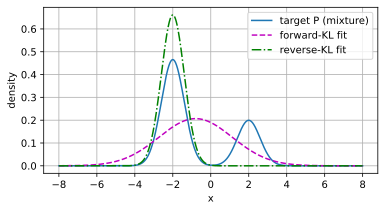

In [4]:
w, mus, sigmas = np.array([0.7, 0.3]), np.array([-2.0, 2.0]), np.array([0.6, 0.6])
x = np.linspace(-8.0, 8.0, 4001)

def log_p(x):
    comps = np.stack([np.log(wi) - 0.5 * np.log(2 * np.pi * si ** 2)
                      - (x - mi) ** 2 / (2 * si ** 2)
                      for wi, mi, si in zip(w, mus, sigmas)])
    cmax = comps.max(axis=0)
    return cmax + np.log(np.exp(comps - cmax).sum(axis=0))

def log_q(x, theta):
    mu, log_sigma = theta
    return (-0.5 * np.log(2 * np.pi) - log_sigma
            - (x - mu) ** 2 / (2 * np.exp(2 * log_sigma)))

def kl(log_a, log_b):
    """D_KL(A||B) on the grid, by quadrature; in nats."""
    return integrate.trapezoid(np.exp(log_a) * (log_a - log_b), x)

fwd = lambda th: kl(log_p(x), log_q(x, th))     # D_KL(P || Q_theta)
rev = lambda th: kl(log_q(x, th), log_p(x))     # D_KL(Q_theta || P)

th_fwd = optimize.minimize(fwd, x0=[0.0, 0.0], method='Nelder-Mead').x
th_rev = optimize.minimize(rev, x0=[0.0, 0.0], method='Nelder-Mead').x
th_rev2 = optimize.minimize(rev, x0=[2.5, -0.5], method='Nelder-Mead').x

for name, th, val in [('forward KL', th_fwd, fwd(th_fwd)),
                      ('reverse KL', th_rev, rev(th_rev)),
                      ('reverse KL, 2nd start', th_rev2, rev(th_rev2))]:
    print(f'{name:22s} mu = {th[0]:+.3f}, sigma = {np.exp(th[1]):.3f}, '
          f'KL = {val:.3f} nats')

d2l.plot(x, [np.exp(log_p(x)), np.exp(log_q(x, th_fwd)),
             np.exp(log_q(x, th_rev))], 'x', 'density',
         legend=['target P (mixture)', 'forward-KL fit', 'reverse-KL fit'],
         figsize=(6, 3))

The two objectives choose *different Gaussians for the same target*. The
forward fit lands at $\mu = -0.800$, $\sigma = 1.929$, precisely the
mixture's mean $0.7(-2) + 0.3(2) = -0.8$ and standard deviation
$\sqrt{3.72} \approx 1.929$, as the proposition demands: a broad Gaussian
draped across both modes, with substantial mass in the valley between them
where $P$ has almost none. The reverse fit lands at $\mu = -1.998$,
$\sigma = 0.603$: it *is* the dominant component, and the minor mode is
simply dropped. Its divergence, $0.356$ nats, is essentially
$\log(1/0.7) \approx 0.357$, the divergence incurred by treating the $70\%$
component as the whole distribution. And reverse KL is genuinely multimodal
as an objective: restarting the optimizer near the minor mode converges to a
*second* local optimum at $\mu = +1.995$ with KL
$\approx 1.202 \approx \log(1/0.3)$ nats. Which local optimum a variational
method finds depends on initialization, a failure mode every practitioner of
variational inference eventually meets.

The generative-modeling translation: maximum-likelihood families
(autoregressive models, normalizing flows) inherit forward KL's
mass-covering: they rarely miss a mode but can produce blurry,
over-dispersed samples; adversarial and variational objectives built on
reverse-type divergences produce sharp samples but can silently drop modes.
The capstone table in that section files every
major objective under exactly this dichotomy.

## Metrics: Total Variation, MMD, and Optimal Transport

The f-divergence family compares densities *pointwise* through the ratio
$p/q$. This section develops the complementary view: divergences defined
through *test functions* and *transport*, which see the geometry of the
sample space and remain estimable and informative when density ratios are
degenerate or unavailable.

### Total Variation and Pinsker's Inequality

The most interpretable distance between distributions answers the question:
*what is the largest disagreement in probability that $P$ and $Q$ assign to
any event?*

$$
\textrm{TV}(P, Q) = \sup_{A} \,\lvert P(A) - Q(A) \rvert.
$$

If $\textrm{TV}(P, Q) = 0.03$, then *no event you can test* will see the two
distributions differ by more than three percentage points. TV is a genuine metric (symmetry is
visible in the equation; the triangle inequality is Exercise 4),
and the supremum has a closed form.

**Proposition (TV is half the $\ell_1$ distance).** *For discrete $P$, $Q$,*

$$
\textrm{TV}(P, Q) = \frac{1}{2} \sum_x \lvert p(x) - q(x) \rvert,
$$

*and the supremum in the equation is attained at
$A^\star = \{x : p(x) > q(x)\}$.*

**Proof.** For any event $A$,
$P(A) - Q(A) = \sum_{x \in A} (p(x) - q(x)) \leq \sum_{x \in A^\star} (p(x) - q(x))$:
enlarging $A$ to include every $x$ with $p(x) > q(x)$ and discarding the rest
only adds non-negative terms and removes non-positive ones. Since
$\sum_x (p(x) - q(x)) = 0$, the positive part equals the negative part in
magnitude, so

$$
\sum_{x \in A^\star} (p(x) - q(x))
= \frac{1}{2} \sum_x \lvert p(x) - q(x) \rvert.
$$

The same argument bounds $Q(A) - P(A)$ by the same quantity. $\blacksquare$

the figure shows the picture: TV is half the total area where
the two densities disagree, and the optimal distinguishing event is simply
"the region where $P$ is the better explanation". This gives TV its
operational meaning. Hand a tester one sample, drawn from $P$ or $Q$ with
equal probability, and ask which distribution produced it: the best possible
test (guess $P$ exactly on $A^\star$) succeeds with probability
$\tfrac{1}{2}\big(1 + \textrm{TV}(P, Q)\big)$, an excess of
$\textrm{TV}/2$ over coin-flipping, which cryptographers double and call the
*advantage*, so that under their convention the best achievable advantage is
exactly $\textrm{TV}(P, Q)$.

![Two densities and the region where they disagree. The total variation distance is half the shaded area, and the event that attains the supremum is the set where the first density exceeds the second: betting on P exactly there is the best possible single-sample test.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-tv-area.svg)

So TV bounds what any test can detect, which makes the next inequality
consequential, because it says *KL bounds TV*. Train a model to small KL
divergence and you have certified indistinguishability against every test.

**Proposition (Pinsker's inequality).** [@Pinsker.1964]

$$
\textrm{TV}(P, Q) \;\leq\; \sqrt{ \tfrac{1}{2}\, D_{\textrm{KL}}(P\|Q) }.
$$

**Proof.** *Step 1: two outcomes.* For $a, b \in (0, 1)$ let
$d(a\|b) = a \log\frac{a}{b} + (1-a) \log\frac{1-a}{1-b}$ be the KL divergence
between coins with heads-probabilities $a$ and $b$; their TV distance is
$|a - b|$, so we must show $d(a\|b) \geq 2(a-b)^2$. Fix $b$ and let
$h(a) = d(a\|b) - 2(a - b)^2$. Then $h(b) = 0$, $h'(b) = 0$, and

$$
h''(a) = \frac{1}{a(1-a)} - 4 \geq 0,
$$

since $a(1-a) \leq \tfrac{1}{4}$. A convex function with value and slope zero
at $a = b$ is non-negative everywhere.

*Step 2: reduction to two outcomes.* Let $A^\star = \{p > q\}$, and set
$a = P(A^\star)$, $b = Q(A^\star)$, so that
$\textrm{TV}(P, Q) = a - b$ by the previous proposition. Merging the outcomes
inside $A^\star$ and inside its complement can only *decrease* KL: by the
log-sum inequality (for non-negative numbers,
$\sum_i a_i \log\frac{a_i}{b_i} \geq \big(\sum_i a_i\big) \log \frac{\sum_i a_i}{\sum_i b_i}$,
itself one application of Jensen to $t \mapsto t\log t$), applied separately
to the terms in $A^\star$ and in its complement,

$$
D_{\textrm{KL}}(P\|Q) \;\geq\; d(a\|b) \;\geq\; 2(a - b)^2
= 2\,\textrm{TV}(P, Q)^2,
$$

which rearranges to the equation. $\blacksquare$

The merging step, that coarsening the outcome space cannot increase an
f-divergence, holds in full generality, and the proof above already contains
the general argument.

**Remark (data-processing for f-divergences).** *Passing $P$ and $Q$ through
any channel $K$ (any deterministic or random map from $x$ to $y$, with
output distributions $(pK)(y) = \sum_x K(y \mid x)\, p(x)$ and likewise
$qK$) can only lose distinguishability:*

$$
D_f(PK \,\|\, QK) \;\leq\; D_f(P\|Q).
$$

**Proof.** Since $\sum_y K(y \mid x) = 1$,
$D_f(P\|Q) = \sum_y \sum_x K(y \mid x)\, q(x)\, f\big(p(x)/q(x)\big)$. For
each fixed $y$, Jensen's inequality with weights proportional to
$K(y \mid x)\, q(x)$, applied at the points $p(x)/q(x)$, moves $f$ outside
the inner sum and leaves exactly the $y$-th term of $D_f(PK\|QK)$; summing
over $y$ with $(qK)(y) > 0$ finishes, since terms with $(qK)(y) = 0$
contribute nothing. $\blacksquare$

Merging outcomes is the deterministic special case used above, and the
data-processing inequality for *mutual information*, which
that section states and proves, is the same
principle in its best-known form. Note also what Pinsker does *not* say: it has no useful converse.
TV is bounded by $1$ while KL is unbounded, so the bound goes slack for
distant pairs (two unit-variance Gaussians $50$ apart have
$\textrm{TV} \approx 1$ but KL $= 1250$ nats), and small TV does *not* imply
small KL (a model can assign $q = 0$ to a rare event and have infinite KL at
tiny TV). Let's check both the bound and its tightness numerically: first
over $10{,}000$ random pairs of distributions on five outcomes, then on pairs
of coins approaching each other, where the binary-case analysis says the
ratio should approach $1$.

In [5]:
rng = np.random.default_rng(0)
worst = 0.0
for _ in range(10000):
    pr, qr = rng.dirichlet(np.ones(5)), rng.dirichlet(np.ones(5))
    tv = 0.5 * np.abs(pr - qr).sum()
    kl_pq = np.sum(pr * np.log(pr / qr))
    worst = max(worst, tv / np.sqrt(0.5 * kl_pq))
print(f'max TV / sqrt(KL/2) over 10,000 random pairs: {worst:.4f}')

for eps in (0.1, 0.01, 0.001):
    pr, qr = np.array([0.5, 0.5]), np.array([0.5 + eps, 0.5 - eps])
    tv = 0.5 * np.abs(pr - qr).sum()
    kl_pq = np.sum(pr * np.log(pr / qr))
    print(f'coins 1/2 vs 1/2+{eps}: TV / sqrt(KL/2) = '
          f'{tv / np.sqrt(0.5 * kl_pq):.6f}')

max TV / sqrt(KL/2) over 10,000 random pairs: 0.9926
coins 1/2 vs 1/2+0.1: TV / sqrt(KL/2) = 0.989881
coins 1/2 vs 1/2+0.01: TV / sqrt(KL/2) = 0.999900
coins 1/2 vs 1/2+0.001: TV / sqrt(KL/2) = 0.999999


The ratio $\textrm{TV}/\sqrt{\textrm{KL}/2}$ never exceeds $1$ (the worst of
$10{,}000$ random pairs reaches $0.9926$), and on nearly-fair coins it climbs
to $0.999999$: the constant $\tfrac{1}{2}$ is the best possible (Exercise 5),
a sharpening due to Csiszár [@Csiszar.1967] rather than to Pinsker's
original argument.

### Integral Probability Metrics and MMD

Total variation's definition, a supremum of differences over events,
generalizes wholesale. Replace indicator functions of events by an arbitrary
class $\mathcal{F}$ of test functions and you get the **integral probability
metrics** [@Muller.1997]:

$$
\textrm{IPM}_{\mathcal{F}}(P, Q)
= \sup_{f \in \mathcal{F}} \,\big( E_{x \sim P}[f(x)] - E_{x \sim Q}[f(x)] \big).
$$

The class $\mathcal{F}$ is a panel of auditors; the IPM reports the largest
discrepancy any auditor in the panel can certify. Three choices of panel give
three famous distances: bounded functions
$\mathcal{F} = \{f : \|f\|_\infty \leq \tfrac{1}{2}\}$ recover total
variation; 1-Lipschitz functions give the Wasserstein-1 distance (next
subsection); and the unit ball of a *reproducing kernel Hilbert space* gives
the **maximum mean discrepancy** [@Gretton.Borgwardt.Rasch.ea.2012].
Contrast the structure with the equation:
f-divergences integrate a function of the *density ratio* and need densities;
IPMs compare *expectations* and need only samples.

MMD is the member built for computation. A **kernel** $k(x, y)$ is a
symmetric, positive-definite similarity function; the standard example is
the RBF kernel $k(x,y) = \exp(-\|x - y\|^2 / (2\ell^2))$, which scores two
points by how close they are on the length scale $\ell$. Every such kernel
generates a *reproducing kernel Hilbert space* (RKHS) $\mathcal{H}$, a space
of functions in which $k(x, \cdot)$ evaluates: $f(x) = \langle f,
k(x, \cdot) \rangle_{\mathcal{H}}$, the *reproducing property*. (Kernels and
their Hilbert spaces are developed at length in [@Scholkopf.Smola.2002];
these two facts are all we need.) Every distribution gets a *mean embedding*
$\mu_P = E_{x \sim P}[k(x, \cdot)] \in \mathcal{H}$, its average feature
function; for bounded kernels the embedding exists and expectations commute
with inner products, so for $f$ in the unit
ball the reproducing property turns expectations into inner products,
$E_P[f] - E_Q[f] = \langle f, \mu_P - \mu_Q \rangle_{\mathcal{H}}$. The
supremum over the unit ball of an inner product against a fixed vector is
that vector's norm, so the IPM collapses to
$\textrm{MMD}(P, Q) = \|\mu_P - \mu_Q\|_{\mathcal{H}}$, and squaring expands
the norm into three kernel expectations:

$$
\textrm{MMD}^2(P, Q)
= E_{x, x' \sim P}[k(x, x')] + E_{y, y' \sim Q}[k(y, y')]
- 2\, E_{x \sim P, y \sim Q}[k(x, y)].
$$

Within-sample similarity under $P$, plus within-sample similarity under $Q$,
minus twice the across-sample similarity: if the two samples interleave, the
three terms cancel; if they form separate clumps, the within terms beat the
across term. Replacing expectations by sample averages, *excluding* the
diagonal terms $k(x_i, x_i)$ whose inclusion would bias the within-sample
terms upward, gives the standard unbiased estimator
[@Gretton.Borgwardt.Rasch.ea.2012], computable in a few lines with no
optimization and no densities. For *characteristic* kernels (the
RBF kernel is one) the embedding $P \mapsto \mu_P$ is injective, so MMD is a
genuine metric: zero only at equality.

In [6]:
def mmd2_unbiased(x, y, ell=1.0):
    """Unbiased MMD^2 with the RBF kernel exp(-(a-b)^2 / (2 ell^2))."""
    k = lambda a, b: np.exp(-(a[:, None] - b[None, :]) ** 2 / (2 * ell ** 2))
    kxx, kyy, kxy = k(x, x), k(y, y), k(x, y)
    n, m = len(x), len(y)
    return ((kxx.sum() - np.trace(kxx)) / (n * (n - 1))
            + (kyy.sum() - np.trace(kyy)) / (m * (m - 1))
            - 2 * kxy.mean())

rng = np.random.default_rng(3)
n = 250
x1, y_same = rng.standard_normal(n), rng.standard_normal(n)
y_shift = rng.standard_normal(n) + 0.5
print(f'MMD^2, same distribution : {mmd2_unbiased(x1, y_same):+.5f}')
print(f'MMD^2, mean shifted 0.5  : {mmd2_unbiased(x1, y_shift):+.5f}')

MMD^2, same distribution : +0.00054
MMD^2, mean shifted 0.5  : +0.05890


Two samples from the same standard Gaussian give
$\textrm{MMD}^2 \approx 0.0005$ (noise around zero; the unbiased
estimator is even allowed to go slightly negative), while shifting one
sample's mean by half a standard deviation produces $\approx 0.059$, two
orders of magnitude larger and consistent, up to sampling noise at
$n = 250$, with the population value $\approx 0.047$ that Exercise 8
derives in closed form. This
sample-only, optimization-free property is why MMD powers kernel two-sample
tests and adversary-free generative training (MMD-GANs and generative moment
matching [@Li.Chang.Cheng.ea.2017; @Li.Swersky.Zemel.2015]): the "critic" is the whole RKHS ball
at once, and the equation evaluates its supremum in closed form.

### Optimal Transport and the Wasserstein Distance

Every divergence so far shares a blind spot. Let $P = \delta_0$ be a point
mass at the origin and $Q_d = \delta_d$ a point mass at distance $d$. For any
$d \neq 0$ the supports are disjoint, so the density ratio is degenerate
everywhere and *every f-divergence is a constant*:
$D_{\textrm{KL}} = \infty$, $\textrm{TV} = 1$, $\textrm{JS} = \log 2$,
whether $d = 0.01$ or $d = 100$. A generator early in training is in exactly
this situation (its samples and the data occupy disjoint slivers of image
space), and an objective that is *constant* in the generator's parameters
supplies zero gradient. This is the vanishing-gradient pathology of GAN
training, and it is a property of the divergence, not of the optimizer
[@Arjovsky.Chintala.Bottou.2017].

What survives disjoint supports is geometry: $\delta_{0.01}$ is *near*
$\delta_0$ because mass need only move $0.01$. The **Wasserstein-1
distance** (earth-mover's distance) makes this precise. A **coupling**
$\gamma$ of $P$ and $Q$ is a joint distribution over pairs $(x, y)$ with
marginals $P$ and $Q$ (a transport plan specifying how much mass travels
from each source to each destination, as in
the figure), and

$$
W_1(P, Q) = \inf_{\gamma \in \Pi(P, Q)} E_{(x, y) \sim \gamma}\big[ \|x - y\| \big],
$$

the cheapest total mass-times-distance over all plans, for $P$ and $Q$ with
finite first moments (without that hypothesis the infimum may be infinite).
On the point masses,
$W_1(\delta_0, \delta_d) = |d|$: smooth in $d$, gradient $\pm 1$, exactly
the training signal the f-divergences withheld.

![Optimal transport between two distributions on the line. Left: the transport plan moves each parcel of mass from source to destination, and the Wasserstein-1 distance is the minimum total mass-times-distance; the shaded area between the two CDFs computes it exactly. Right: for two point masses at separation d, the Jensen--Shannon divergence is frozen at log 2 for every nonzero d while the Wasserstein distance grows linearly: only transport gives a gradient.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-ot-transport-plan.svg)

The primal the equation is an optimization over joint
distributions, hard to even parameterize from samples. Its dual is the
reason $W_1$ matters to deep learning.

**Proposition (Kantorovich--Rubinstein duality).**

$$
W_1(P, Q) = \sup_{\|f\|_{\textrm{Lip}} \leq 1}
\big( E_{x \sim P}[f(x)] - E_{y \sim Q}[f(y)] \big),
$$

*where the supremum runs over all 1-Lipschitz functions
($|f(x) - f(y)| \leq \|x - y\|$ for all $x, y$).*

We will not prove the general statement (see
@Peyre.Cuturi.2019 for a proof and for optimal transport at large),
but here is why it is plausible, in one economic metaphor that goes back to
Kantorovich. Interpret $f(x)$ as a *price* paid per unit of mass at location
$x$. A logistics contractor offers: "rather than moving the mass yourself,
sell it to me at your sources and buy it back at your destinations; I pocket
$E_P[f] - E_Q[f]$." You would accept any offer where the price gradient is
nowhere steeper than the transport cost (the 1-Lipschitz
condition), because then no parcel's price difference exceeds its shipping
cost, term by term, under any plan you might have used; this gives weak
duality ($\textrm{sup} \leq \textrm{inf}$, compare
that section). The content of the theorem is that
the *best* contractor extracts the *entire* transport cost. So $W_1$ is the
1-Lipschitz IPM: the test class in the equation becomes the
functions with slope at most $1$. The **WGAN** [@Arjovsky.Chintala.Bottou.2017]
trains exactly this dual: a neural critic plays the role of $f$, constrained
to be (approximately) 1-Lipschitz, by weight clipping originally, then by
gradient penalties [@Gulrajani.Ahmed.Arjovsky.ea.2017] (penalizing
$\|\nabla f\| \neq 1$, since an optimal Kantorovich potential has unit slope
along transport rays) and by spectral normalization
[@Miyato.Kataoka.Koyama.ea.2018], which caps each layer's Lipschitz
constant through its largest singular value
(that section).

In one dimension, optimal transport collapses to a formula with no
optimization left in it.

**Proposition (1-D Wasserstein in closed form).** *For distributions on
$\mathbb{R}$ with CDFs $F_P$ and $F_Q$ and finite first moments, granting
the duality the equation,*

$$
W_1(P, Q) = \int_{-\infty}^{\infty} \lvert F_P(t) - F_Q(t) \rvert \, dt.
$$

**Proof.** Let $f$ be 1-Lipschitz; then $f$ is absolutely continuous with
$|f'(t)| \leq 1$ wherever the derivative exists, and
$f(x) = f(0) + \int_0^x f'(t)\, dt$, a standard fact of real analysis
[@Folland.1999] that we grant. The constant $f(0)$ cancels in
$E_P[f] - E_Q[f]$. For $X \sim P$, writing the inner integral with
indicators, $\int_0^X f'(t)\,dt = \int_0^{\infty} f'(t)\, \mathbf{1}[X > t]\, dt
- \int_{-\infty}^0 f'(t)\, \mathbf{1}[X \leq t]\, dt$, and swapping
expectation and integral (Fubini's theorem from
that section, justified by the moment assumption),

$$
E_P\!\left[ \int_0^X f'(t)\, dt \right]
= \int_0^{\infty} f'(t)\,(1 - F_P(t))\, dt - \int_{-\infty}^0 f'(t)\, F_P(t)\, dt.
$$

Subtracting the same expression for $Q$, the constants cancel and both pieces
merge into one integral over all of $\mathbb{R}$:

$$
E_P[f] - E_Q[f] = \int_{-\infty}^{\infty} f'(t)\, \big( F_Q(t) - F_P(t) \big)\, dt
\;\leq\; \int_{-\infty}^{\infty} \lvert F_P(t) - F_Q(t) \rvert\, dt,
$$

using $|f'| \leq 1$. Equality is attained by integrating the choice
$f'(t) = \mathrm{sign}\big(F_Q(t) - F_P(t)\big)$, which defines a 1-Lipschitz
function. By Kantorovich--Rubinstein the equation the supremum of
the left side over 1-Lipschitz $f$ is $W_1$, proving
the equation. $\blacksquare$

Geometrically, $W_1$ is the *area between the two CDFs* (the shaded region of
the figure). Slicing that area horizontally instead
of vertically gives the equivalent quantile form
$W_1 = \int_0^1 |F_P^{-1}(u) - F_Q^{-1}(u)|\, du$, which for two equal-size
empirical samples is just the mean absolute difference of their *sorted*
values (Exercise 7). Let's verify the equation against the primal
the equation, solved exactly as a linear program over transport
plans (the plan $\gamma$ is a matrix with row sums $p$ and column sums $q$,
compare that section).

In [7]:
atoms = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
p_w = np.array([0.30, 0.20, 0.25, 0.10, 0.10, 0.05])
q_w = np.array([0.05, 0.10, 0.10, 0.25, 0.20, 0.30])

F_p, F_q = np.cumsum(p_w), np.cumsum(q_w)
w1_cdf = np.sum(np.abs(F_p - F_q)[:-1] * np.diff(atoms))

C = np.abs(atoms[:, None] - atoms[None, :])      # cost matrix |x_i - y_j|
k = len(atoms)
A_eq = np.zeros((2 * k, k * k))
for i in range(k):
    A_eq[i, i * k:(i + 1) * k] = 1               # row sums    = p
    A_eq[k + i, i::k] = 1                        # column sums = q
res = optimize.linprog(C.ravel(), A_eq=A_eq,
                       b_eq=np.concatenate([p_w, q_w]), method='highs')
print(f'W1 via the CDF formula : {w1_cdf:.10f}')
print(f'W1 via the primal LP   : {res.fun:.10f}')

W1 via the CDF formula : 1.7000000000
W1 via the primal LP   : 1.7000000000


Both routes give $W_1 = 1.7$ to ten decimal places: a one-line integral of
CDFs replaces a $36$-variable linear program.

Beyond one dimension no such formula exists, and the LP scales poorly: with
$n$ atoms a side it has $n^2$ variables. The standard fix at scale is **entropic
regularization** [@Cuturi.2013]: add $-\varepsilon H(\gamma)$ to the
primal objective, penalizing low-entropy (overly deterministic) plans. The
regularized problem is strictly convex and its solution has the form
$\gamma = \mathrm{diag}(u)\, K\, \mathrm{diag}(v)$ with
$K = e^{-C/\varepsilon}$, where the **Sinkhorn iterations** (alternately
rescaling rows to match $p$ and columns to match $q$) converge fast, run on
matrix-vector products (GPU-friendly), and are differentiable end to end. As
$\varepsilon \to 0$ the entropic cost recovers the unregularized optimum
[@Peyre.Cuturi.2019].

epsilon = 1.00: entropic cost = 1.7700   (unregularized LP: 1.7000)
epsilon = 0.10: entropic cost = 1.7000   (unregularized LP: 1.7000)
epsilon = 0.02: entropic cost = 1.7000   (unregularized LP: 1.7000)


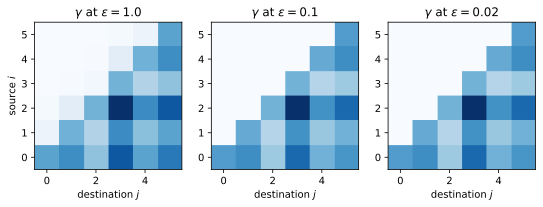

In [8]:
def sinkhorn(p, q, C, eps, iters=5000):
    """Entropic OT by Sinkhorn iterations; returns plan and cost."""
    K = np.exp(-C / eps)
    u = np.ones_like(p)
    for _ in range(iters):
        v = q / (K.T @ u)
        u = p / (K @ v)
    plan = u[:, None] * K * v[None, :]
    return plan, np.sum(plan * C)

fig, axes = d2l.plt.subplots(1, 3, figsize=(9, 2.8))
axes[0].set_ylabel('source $i$')
for ax, eps in zip(axes, (1.0, 0.1, 0.02)):
    plan, cost = sinkhorn(p_w, q_w, C, eps)
    print(f'epsilon = {eps:4.2f}: entropic cost = {cost:.4f}'
          f'   (unregularized LP: {res.fun:.4f})')
    ax.imshow(plan, cmap='Blues', origin='lower')
    ax.set_title(f'$\\gamma$ at $\\varepsilon = {eps}$')
    ax.set_xlabel('destination $j$')

At $\varepsilon = 1$ the blurred plan costs more ($1.77$ vs. $1.70$); by
$\varepsilon = 0.1$ the entropic cost matches the LP to four decimals. The
heatmaps show why. At $\varepsilon = 1$ entropy dominates and the plan is a
haze: every source hedges its mass across many destinations, close to the
independent coupling $p\, q^\top$, so parcels take detours and the cost runs
high. Shrinking $\varepsilon$ anneals the haze away: the plan sharpens
toward a vertex of the transport polytope (an extreme point of the set of
feasible plans), and at $\varepsilon = 0.02$ only
a thin monotone staircase of routes survives, the never-crossing assignment
that one-dimensional optimal transport always produces and the LP finds
exactly. With squared cost $\|x - y\|^2$ in
the equation one obtains the Wasserstein-2 distance, whose
dynamical (Benamou--Brenier) formulation as a minimum-kinetic-energy flow is
the natural language for diffusion models and flow matching; we develop it
where it is needed, in that section.

## Scores: Fisher Divergence, Stein Discrepancy, and the Objective Map

One last family compares distributions through *derivatives* of their
log-densities. It looks exotic until you notice that it is the only family
that never asks for a normalizing constant, which is exactly the term modern
energy-based and diffusion models cannot compute.

### The Score and the Fisher Divergence

The **score** of a distribution $P$ with differentiable density $p$ is the
gradient of its log-density *with respect to the data point*:

$$
s_P(\mathbf{x}) = \nabla_{\mathbf{x}} \log p(\mathbf{x}).
$$

(A terminology hazard: in classical statistics, "score" means the gradient
with respect to *parameters*, $\nabla_{\boldsymbol{\theta}} \log
p_{\boldsymbol{\theta}}(\mathbf{x})$, the object behind maximum likelihood
and Fisher information in that section. Here the
gradient is in $\mathbf{x}$; this *data score* is the one that
that section builds diffusion models
from.) The score is a vector field on the sample space, pointing in the
direction in which the density increases fastest: "uphill, toward where the
mass is", as the figure shows. For a Gaussian
$\mathcal{N}(\mu, \sigma^2)$ it is

$$
s(x) = -\frac{x - \mu}{\sigma^2},
$$

a spring pulling toward the mean with stiffness $1/\sigma^2$; for a mixture
$p = \sum_k w_k\, p_k$ the chain rule gives
$s(x) = \sum_k r_k(x)\, s_k(x)$ with
$r_k(x) = w_k p_k(x) / p(x)$: each component's spring, weighted by the
posterior probability ("responsibility") that $x$ came from it.

![The score field of a two-component Gaussian mixture. Arrows show the gradient of the log-density: near each mode the field is a spring pulling toward that mode's mean, and along the valley between modes the responsibilities hand the point off from one attractor to the other. Density contours are underlaid for reference.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-score-field.svg)

The property that earns the score its central role is one line long. Suppose
we can only write the density up to a constant,
$p(\mathbf{x}) = \tilde{p}(\mathbf{x}) / Z$ with
$Z = \int \tilde{p}$ intractable, the universal situation for energy-based
models. Then

$$
\nabla_{\mathbf{x}} \log p(\mathbf{x})
= \nabla_{\mathbf{x}} \log \tilde{p}(\mathbf{x})
- \nabla_{\mathbf{x}} \log Z
= \nabla_{\mathbf{x}} \log \tilde{p}(\mathbf{x}),
$$

since $Z$ does not depend on $\mathbf{x}$. *The score never sees the
normalizer.* A divergence built from scores therefore lets us fit
unnormalized models, and the natural choice is the mean squared mismatch of
the two vector fields under the data distribution, the **Fisher
divergence**:

$$
D_{\textrm{F}}(P\|Q) = \frac{1}{2}\, E_{\mathbf{x} \sim P}\!\left[
\big\| \nabla_{\mathbf{x}} \log p(\mathbf{x})
- \nabla_{\mathbf{x}} \log q(\mathbf{x}) \big\|^2 \right].
$$

It is non-negative. If $p$ and $q$ are positive on the same connected support,
score equality $P$-almost everywhere forces $\log p-\log q$ to be constant
there, and normalization then gives $P=Q$. Connected support of $P$ alone is
not enough: $Q$ could agree with $P$ on that support while assigning additional
mass elsewhere. For two
equal-variance Gaussians the scores differ by the constant
$(\mu_2 - \mu_1)/\sigma^2$, so
$D_{\textrm{F}} = (\mu_1 - \mu_2)^2 / (2\sigma^4)$; compare KL's
$(\mu_1 - \mu_2)^2/(2\sigma^2)$ from the equation; the general
unequal-variance form is Exercise 9. Let's verify the mixture score formula,
the normalizer-blindness, and the Gaussian closed form numerically.

In [9]:
def score_p(x):
    """Score of the mixture P: responsibility-weighted component scores."""
    log_comps = np.stack([np.log(wi) - 0.5 * np.log(2 * np.pi * si ** 2)
                          - (x - mi) ** 2 / (2 * si ** 2)
                          for wi, mi, si in zip(w, mus, sigmas)])
    r = np.exp(log_comps - log_p(x))             # responsibilities r_k(x)
    comp_scores = np.stack([-(x - mi) / si ** 2 for mi, si in zip(mus, sigmas)])
    return np.sum(r * comp_scores, axis=0)

numeric = np.gradient(log_p(x), x)               # numerical d/dx log p
gap = np.abs(score_p(x) - numeric)[10:-10].max()
print(f'mixture score, max |analytic - numerical|: {gap:.2e}')
shifted = np.gradient(np.log(2.7) + log_p(x), x)  # unnormalized: 2.7 * p
print(f'score change from rescaling p by 2.7    : '
      f'{np.abs(shifted - numeric).max():.2e}')

mu1, s1, mu2, s2 = 0.0, 1.0, 1.0, 1.0
xs = np.linspace(-10.0, 12.0, 4001)
pdf1 = np.exp(-(xs - mu1) ** 2 / (2 * s1 ** 2)) / np.sqrt(2 * np.pi * s1 ** 2)
sc1, sc2 = -(xs - mu1) / s1 ** 2, -(xs - mu2) / s2 ** 2
fisher = 0.5 * integrate.trapezoid(pdf1 * (sc1 - sc2) ** 2, xs)
print(f'Fisher divergence N(0,1)||N(1,1): quadrature {fisher:.6f}, '
      f'closed form {(mu1 - mu2) ** 2 / (2 * s1 ** 4):.6f}')

mixture score, max |analytic - numerical|: 3.52e-04
score change from rescaling p by 2.7    : 1.82e-12
Fisher divergence N(0,1)||N(1,1): quadrature 0.500000, closed form 0.500000


The analytic mixture score matches the numerical gradient of $\log p$ to the
grid's finite-difference accuracy ($\approx 3.5 \times 10^{-4}$), rescaling
the density by $2.7$ changes the score by nothing but floating-point dust
($\approx 2 \times 10^{-12}$), and the quadrature reproduces the Gaussian
closed form $0.5$ to six decimals.

One apparent obstacle remains: the equation is an
expectation involving $\nabla \log p$ of the *data* distribution, which we do
not know either. The resolution, Hyvärinen's **score matching** identity
[@Hyvarinen.2005], is an integration by parts showing that, up to a
constant independent of the model,

$$
D_{\textrm{F}}(P\|Q_{\boldsymbol{\theta}}) = E_{\mathbf{x} \sim P}\!\left[
\tfrac{1}{2} \|\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x})\|^2
+ \nabla_{\mathbf{x}} \cdot \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x})
\right] + \textrm{const},
$$

an objective containing *only the model's score*
$\mathbf{s}_{\boldsymbol{\theta}}$, estimable from data samples alone. We
state it here and prove it, together with its denoising variant (the actual
training loss of diffusion models), in
that section.

### Stein's Identity

The score can also *test* a sample. The starting point is a fact
about expectations under a distribution whose score we know.

**Proposition (Stein's identity).** [@Stein.1981] *Let $P$ have a differentiable density
$p > 0$ on $\mathbb{R}$ with score $s_P = (\log p)'$, and let $f$ be
differentiable with $f(x)\, p(x) \to 0$ as $x \to \pm\infty$. Then*

$$
E_{x \sim P}\big[ f'(x) + f(x)\, s_P(x) \big] = 0.
$$

**Proof.** Since $p' = s_P\, p$, integration by parts
(that section) gives

$$
\int f'(x)\, p(x)\, dx
= \big[ f(x)\, p(x) \big]_{-\infty}^{\infty} - \int f(x)\, p'(x)\, dx
= 0 - \int f(x)\, s_P(x)\, p(x)\, dx,
$$

and moving the right-hand side over is the equation.
$\blacksquare$

For $P = \mathcal{N}(0, 1)$ the score is $s_P(x) = -x$ and the identity reads
$E[f'(X)] = E[X f(X)]$; with $f(x) = x$ it recovers $E[X^2] = 1$. The point
is that the identity holds for *huge classes of $f$ simultaneously*, and only
for $P$ itself: if a sample's averages violate
the equation for some $f$, the sample is not from $P$.
A Monte-Carlo check of the equation:

In [10]:
rng = np.random.default_rng(7)
z = rng.standard_normal(1_000_000)
# Stein operator for P = N(0,1):  (A_P f)(x) = f'(x) - x f(x)
for name, f, fprime in [('x^3', lambda t: t ** 3, lambda t: 3 * t ** 2),
                        ('sin x', np.sin, np.cos)]:
    val = (fprime(z) - z * f(z)).mean()
    print(f"E[ f'(Z) - Z f(Z) ] for f(x) = {name}: {val:+.4f}")

E[ f'(Z) - Z f(Z) ] for f(x) = x^3: +0.0020
E[ f'(Z) - Z f(Z) ] for f(x) = sin x: +0.0005


Both averages ($+0.0020$ and $+0.0005$ on a million samples) are zero to
within Monte-Carlo error, for two quite different test functions, a glimpse
of the infinite family of constraints the identity imposes.

### The Kernel Stein Discrepancy

To turn the identity into a divergence, run the IPM construction of
that section on it: apply the **Stein operator**
$(\mathcal{A}_P f)(x) = f'(x) + f(x)\, s_P(x)$ to every $f$ in the unit ball
of an RKHS and take the largest violation,
$\sup_{\|f\|_{\mathcal{H}} \leq 1} E_{x \sim Q}[(\mathcal{A}_P f)(x)]$. By
Stein's identity the supremum is zero when $Q = P$; when $Q \neq P$, some
test function witnesses the mismatch. Exactly as with MMD, the supremum over
an RKHS ball has a closed form: it is the square root of an expected kernel.
For a positive-definite kernel $k$ and score
$s_P = \nabla \log p$, define the **Stein kernel** of $P$,

$$
\begin{aligned}
u_P(\mathbf{x}, \mathbf{x}') = {}& s_P(\mathbf{x})^\top k(\mathbf{x}, \mathbf{x}')\, s_P(\mathbf{x}')
+ s_P(\mathbf{x})^\top \nabla_{\mathbf{x}'} k(\mathbf{x}, \mathbf{x}') \\
&+ \nabla_{\mathbf{x}} k(\mathbf{x}, \mathbf{x}')^\top s_P(\mathbf{x}')
+ \nabla_{\mathbf{x}} \cdot \nabla_{\mathbf{x}'} k(\mathbf{x}, \mathbf{x}'),
\end{aligned}
$$

where the last term is the sum of mixed partials
$\sum_i \partial_{x_i} \partial_{x'_i} k$; in one dimension it is just
$\partial_x \partial_{x'} k$. The squared **kernel Stein discrepancy (KSD)**
is the expected Stein kernel under two independent draws from $Q$:

$$
\mathrm{KSD}^2(Q, P) = E_{\mathbf{x}, \mathbf{x}' \sim Q}\big[ u_P(\mathbf{x}, \mathbf{x}') \big].
$$

Three properties make this the right tool for modern models. First,
the equation involves $P$ only through its score, so by the
normalizer-blindness of that section an unnormalized
model works exactly as well as a normalized one, and no samples from $P$ are
ever drawn. Second, for suitable kernels (the RBF kernel among them, under
mild conditions on the score) $\mathrm{KSD}^2(Q, P) = 0$ if and only if
$Q = P$ [@Liu.Lee.Jordan.2016; @Chwialkowski.Strathmann.Gretton.2016].
Third, the equation is a double expectation under $Q$ alone, so a
sample $x_1, \ldots, x_n \sim Q$ gives the unbiased U-statistic estimator

$$
\widehat{\mathrm{KSD}}^2 = \frac{1}{n(n-1)} \sum_{i \neq j} u_P(x_i, x_j),
$$

the same diagonal-excluding average as the MMD estimator. Let's compute it.
For the 1-D RBF kernel $k(x, y) = e^{-(x-y)^2/(2\ell^2)}$ the derivatives in
the equation are closed-form:
$\partial_y k = \frac{x-y}{\ell^2}\, k$,
$\partial_x k = -\frac{x-y}{\ell^2}\, k$, and
$\partial_x \partial_y k = \big( \frac{1}{\ell^2} - \frac{(x-y)^2}{\ell^4} \big)\, k$.
We test one sample from $Q = \mathcal{N}(0, 1)$ against two models: the true
$P = \mathcal{N}(0, 1)$, whose score is $s(x) = -x$, and the wrong
$P' = \mathcal{N}(1, 1)$, whose score is $s(x) = -(x - 1)$.

In [11]:
def ksd2_ustat(x, score, ell=1.0):
    """U-statistic KSD^2 with the RBF kernel exp(-(a-b)^2 / (2 ell^2))."""
    d = x[:, None] - x[None, :]
    k = np.exp(-d ** 2 / (2 * ell ** 2))
    dk_dx = -d / ell ** 2 * k
    dk_dy = d / ell ** 2 * k
    d2k = (1 / ell ** 2 - d ** 2 / ell ** 4) * k
    s = score(x)
    u = (s[:, None] * s[None, :] * k + s[:, None] * dk_dy
         + dk_dx * s[None, :] + d2k)
    n = len(x)
    return (u.sum() - np.trace(u)) / (n * (n - 1))

rng = np.random.default_rng(1)
x_q = rng.standard_normal(1000)          # the sample: Q = N(0, 1)
for name, s in [('true model  N(0,1)', lambda t: -t),
                ('wrong model N(1,1)', lambda t: -(t - 1))]:
    print(f'KSD^2 vs the {name}: {ksd2_ustat(x_q, s):+.5f}')

KSD^2 vs the true model  N(0,1): +0.00019


KSD^2 vs the wrong model N(1,1): +0.64425


Against the true model the U-statistic is $\approx 0.0002$, consistent with
zero (like the unbiased MMD estimator, it may even dip slightly negative);
against the model whose mean is off by one it is $\approx 0.64$, clearly
positive and three orders of magnitude larger, although the *sample* never
changed and $P'$ was never sampled at all: the discrepancy reads the mismatch
straight off the score. This sample-versus-model comparison makes KSD the
natural goodness-of-fit test for unnormalized models
[@Liu.Lee.Jordan.2016], and the descent direction it induces on a
particle set is Stein variational gradient descent (SVGD)
[@Liu.Wang.2016], which transports particles toward $P$ using only its
score.

### The Divergence-to-Objective Map

We can now deliver the payoff promised at the start: a single table that
reads the modern generative objectives as choices of divergence. Each
row names a training objective, the divergence its loss minimizes (often
implicitly), where this section treats it, and the behavior the divergence
makes inevitable.

| Training objective | Divergence minimized | Treated in | Characteristic behavior |
|:---|:---|:---|:---|
| maximum likelihood: autoregressive models, normalizing flows | forward KL | that section | zero-avoiding and often mass-covering; may over-spread |
| variational inference, VAE posterior (ELBO) | reverse KL | that section | mode-seeking; sharp but can drop modes; local optima |
| original GAN | Jensen--Shannon | that section | sharp samples; no gradient on disjoint supports |
| f-GAN | any chosen f-divergence | that section | inherits the chosen generator's behavior; critic-limited |
| WGAN | Wasserstein-1 | that section | gradients survive disjoint supports; needs Lipschitz critic |
| MMD-GAN, two-sample tests | MMD | that section | closed-form, adversary-free; kernel choice sets sensitivity |
| score matching, diffusion models | Fisher divergence | that section | normalizer-free; trains on the score field |
| SVGD, model criticism | kernel Stein discrepancy | that section | needs only the model's score; no model samples |

*Maximum likelihood*
(row 1) is forward KL by the NLL--cross-entropy equivalence of
that section, so a language model trained on
next-token prediction is mass-covering by construction: it would rather
assign some probability to text it will never produce than risk assigning
none to text that occurs. *The GAN family* (rows 3--5) is one design axis:
the original GAN minimizes a bounded f-divergence and inherits its
flat-on-disjoint-supports gradient pathology; WGAN swaps families to optimal
transport, which supplies gradients everywhere but requires a constrained critic.
*Diffusion models* (row 7) sidestep densities entirely: Fisher divergence
compares score fields, the normalizer cancels, and the training loss becomes
a regression onto $\nabla_{\mathbf{x}} \log p$, which is where
that section picks up the story.

The thesis of the table, and of this section: **choose your divergence,
inherit its failure modes.** Mode-dropping, blurriness, vanishing gradients,
and training instability are theorems about the objective, visible in the
geometry of $f$, the direction of the KL, the boundedness of JS, or the
function class of the IPM, before a single parameter is trained.

## Summary

* A divergence demands only $D(P, Q) \geq 0$ with equality iff $P = Q$;
  metrics add symmetry and the triangle inequality. KL is a divergence but
  not a metric; TV, Hellinger, and Wasserstein are metrics.
* f-divergences $D_f(P\|Q) = E_Q[f(p/q)]$ unify KL, reverse KL, $\chi^2$,
  Hellinger, TV, and Jensen--Shannon; non-negativity is Jensen's inequality,
  and near $P = Q$ all smooth members agree up to the factor $f''(1)$. The
  Rényi/$\alpha$ family sweeps between the two KL directions with a single
  knob and appears in differential-privacy accounting.
* Fenchel duality turns any f-divergence into an adversarial game,
  $D_f = \sup_T \{ E_P[T] - E_Q[f^*(T)] \}$, estimable from samples; the
  original GAN is the Jensen--Shannon case, and an undertrained critic
  biases the estimate low.
* The direction of KL is a modeling decision: forward KL (maximum
  likelihood) is zero-avoiding and mass-covering; reverse KL (variational
  inference) is zero-forcing and often mode-seeking on multimodal targets;
  the number and location of local optima depend on the model family.
* Total variation is the largest probability any event can disagree by, and
  Pinsker's inequality $\textrm{TV} \leq \sqrt{D_{\textrm{KL}}/2}$ means
  small KL certifies indistinguishability under every test.
* IPMs replace events by a test-function class; the RKHS ball gives MMD,
  with a closed-form unbiased estimator from samples alone.
* Wasserstein distances measure mass transport and remain informative and
  continuous when supports are disjoint (they need not be differentiable or
  smooth there), equal an integral of CDF differences in 1-D, and
  are computed at scale by entropic regularization and Sinkhorn iterations.
* The score $\nabla_{\mathbf{x}} \log p$ is blind to the normalizing
  constant; the Fisher divergence compares score fields and underlies score
  matching and diffusion; Stein's identity and the kernel Stein discrepancy
  turn the score into goodness-of-fit tests.

## Exercises

1. Recover KL and reverse KL from the template the equation
   with the generators $f(u) = u \log u$ and $f(u) = -\log u$. Then show
   that for any constant $c$, the generators $f(u)$ and $f(u) + c\,(u - 1)$
   define the same divergence, and use this freedom to find a generator for
   reverse KL that is non-negative everywhere.
2. Derive the convex conjugate $f^*(t) = t + t^2/4$ of the $\chi^2$
   generator $f(u) = (u - 1)^2$ over $u \in \mathbb{R}$, then redo the
   computation over the generator's true domain $u \in (0, \infty)$ and show
   that the supremum is $t + t^2/4$ for $t \geq -2$ but $-1$ for $t \leq -2$.
   Explain why plugging the (larger) $\mathbb{R}$-conjugate into
   the equation still yields a valid lower bound, merely a
   weaker one for critics that dip below $-2$. Finally, write the explicit
   f-GAN objective for this generator and verify that the critic
   $T^\star = f'(p/q) = 2(p/q - 1)$ attains the bound with equality.
3. Two point masses at distance $d$: show that $D_{\textrm{KL}}$, TV, and JS
   are constant in $d$ (for $d \neq 0$) while $W_1 = |d|$. What does this
   imply about the gradient each objective supplies to a generator whose
   samples are far from the data?
4. Prove that total variation satisfies the triangle inequality, and decide
   which of KL, reverse KL, squared Hellinger, and $W_1$ are metrics. (For
   the Hellinger *distance* $H = \sqrt{H^2}$, relate it to an $\ell_2$ norm
   of $\sqrt{p} - \sqrt{q}$.)
5. Sharpness of Pinsker: for coins with biases $\tfrac{1}{2}$ and
   $\tfrac{1}{2} + \epsilon$, expand the KL divergence to second order in
   $\epsilon$ to show $D_{\textrm{KL}} = 2\epsilon^2 + O(\epsilon^4)$ and
   conclude that the ratio $\textrm{TV}/\sqrt{D_{\textrm{KL}}/2}$ tends to
   $1$, matching the experiment. Why is the bound loose for two
   unit-variance Gaussians with distant means?
6. Hellinger and total variation control each other. With the squared
   Hellinger divergence of the gallery,
   $H^2(P, Q) = \sum_x \big(\sqrt{p(x)} - \sqrt{q(x)}\big)^2$, and
   $H = \sqrt{H^2}$ the Hellinger distance, prove the two-sided bound

   $$
   \tfrac{1}{2}\, H^2(P, Q) \;\leq\; \textrm{TV}(P, Q)
   \;\leq\; H(P, Q)\, \sqrt{ 1 - \tfrac{1}{4} H^2(P, Q) }.
   $$

   (Hint: write $|p - q| = |\sqrt{p} - \sqrt{q}|\,(\sqrt{p} + \sqrt{q})$.
   The lower bound is $\sqrt{p} + \sqrt{q} \geq |\sqrt{p} - \sqrt{q}|$; the
   upper bound is Cauchy--Schwarz
   (that section) together with
   $\sum_x (\sqrt{p} + \sqrt{q})^2 = 4 - H^2$.) Then verify both
   inequalities numerically over $10{,}000$ random Dirichlet pairs on five
   outcomes, in the style of the Pinsker experiment, and record how close
   each side comes to equality. Unlike Pinsker, this sandwich is two-sided:
   Hellinger and TV agree about which sequences of distributions converge,
   whereas KL can be infinite at arbitrarily small TV.
7. From the equation, derive the quantile form
   $W_1 = \int_0^1 |F_P^{-1}(u) - F_Q^{-1}(u)|\, du$, and show that for two
   empirical distributions on samples $x_1, \ldots, x_n$ and
   $y_1, \ldots, y_n$ it equals $\tfrac{1}{n}\sum_i |x_{(i)} - y_{(i)}|$,
   the mean absolute difference of sorted values. Verify numerically against
   the linear program on a small example.
8. For $P = \mathcal{N}(0, 1)$ and $Q = \mathcal{N}(\delta, 1)$ with the RBF
   kernel of bandwidth $\ell = 1$, use the Gaussian integral
   $E[e^{-Z^2/2}] = (1 + s^2)^{-1/2} e^{-m^2/(2(1+s^2))}$ for
   $Z \sim \mathcal{N}(m, s^2)$ to derive
   $\textrm{MMD}^2 = \tfrac{2}{\sqrt{3}}\big(1 - e^{-\delta^2/6}\big)$.
   Evaluate it at $\delta = 0.5$ and compare with the estimate from the code
   cell.
9. Compute the Fisher divergence between $\mathcal{N}(\mu_1, \sigma_1^2)$
   and $\mathcal{N}(\mu_2, \sigma_2^2)$ in closed form (the score difference
   is affine in $x$, so only Gaussian first and second moments are needed),
   and check it reduces to $(\mu_1 - \mu_2)^2/(2\sigma^4)$ for equal
   variances. Then verify Stein's identity the equation
   for $\mathcal{N}(0, 1)$ with $f(x) = x$ by hand. What classical fact
   about the standard Gaussian do you recover?

[Discussions](https://d2l.discourse.group/t/divergences)